# Filtering overlapping ChIP-seq peaks

HepG2 ChIP-seq binding-site files used for downstream analyses.

Starting from 208 TF/CAP ChIP-seq datasets (GSE104247), overlapping peaks within each dataset are resolved by retaining the peak with the highest `signalValue`. TFBS datasets with low numbers of retained sites are then removed using the 25th percentile of the site-count distribution as the cutoff, resulting in 156 TFBS datasets for downstream analyses.

#### This notebook contains

1. Reading the 208 TF/CAP ChIP-seq peak files.
2. Removing overlapping peaks within each TF/CAP dataset while retaining the peak with the highest binding signal.
3. Counting the number of retained binding sites for each dataset and filtering based on the 25th percentile of the site-count distribution.
4. Adding TF/CAP annotations from the occupancy map metadata.

Input data are not uploaded to this repository. See `data/README.md` for data sources and file locations.


In [2]:
#libraries
import numpy as np
from numpy.polynomial import polynomial as poly
import pandas as pd
from pathlib import Path
import pybedtools as pbt
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

def find_repo_root():
    "'repository root'"
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "results").exists():
            return path

    raise FileNotFoundError("Could not locate repository root.")

REPO_ROOT = find_repo_root()

In [ ]:
# path to folders
CHIP_DIR = REPO_ROOT / "data" / "raw" / "chip_seq" / "Sorted208TFBS"
ANNOT_FILE = REPO_ROOT / "data" / "raw" / "metadata" / "Occupancy_maps_supp1_CAPinfo.csv"

OUTPUT_DIR = REPO_ROOT / "results" / "preprocessing"
TABLE_DIR = REPO_ROOT / "results" / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [11]:
chip_files = sorted(CHIP_DIR.iterdir())

print("Number of files:", len(chip_files))

for file in chip_files[:10]:
    print(file.name)

Number of files: 208
GSM2797484_ARID3A_human_IDR0.02_narrowPeak_sorted.bed
GSM2797485_ARID4B_FLAG_IDR0.02_narrowPeak_sorted.bed
GSM2797486_ARID5B_FLAG_IDR0.02_narrowPeak_sorted.bed
GSM2797487_ASH2L_human_IDR0.02_narrowPeak_sorted.bed
GSM2797488_ATF1_FLAG_IDR0.02_narrowPeak_sorted.bed
GSM2797489_ATF3_IDR0.02_narrowPeak_sorted.bed
GSM2797490_ATF4_FLAG_IDR0.02_narrowPeak_sorted.bed
GSM2797491_BACH1_human_IDR0.02_narrowPeak_sorted.bed
GSM2797492_BCL6_iso1_FLAG_IDR0.02_narrowPeak_sorted.bed
GSM2797493_BHLHE40_human_IDR0.02_narrowPeak_sorted.bed


Chip seq bed files are in MACS2 narrowPeak (BED6+4) format. The columns correspond to chromosome, start, end, peak name, score, strand, signalValue, pValue, qValue and peak position.

signalValue represents the enrichment signal associated with each peak and is used here to select between overlapping peaks.


##### Using these column names to identify our columns and add them all to a df

In [12]:
narrowpeak_columns = [
    "Chrom","ChromStart","ChromEnd","BedName","Score",
    "Strand","Signal","pValue","qValue","Peak"
]

#### Adding the ChIP sites of all TFs/CAPS into a df

In [13]:
frames = []

# Read all ChIP-seq peak files
for file in sorted(CHIP_DIR.iterdir()):
    if not file.is_file():
        continue

    df = pd.read_csv(file, sep="\t", header=None,names=narrowpeak_columns)

    # Get TF/CAP name from the filename as Gene
    df["Gene"] = file.name.split("_")[1]

    # Compute peak length
    df["Site length"] = df["ChromEnd"] - df["ChromStart"]
    frames.append(df)

# Combine all TF/CAP datasets into one dataframe
TFBS_df_og = pd.concat(frames, ignore_index=True)

TFBS_df_og

,Chrom,ChromStart,ChromEnd,BedName,Score,Strand,Signal,pValue,qValue,Peak,Gene,Site length
0,chr1,1310515,1310891,.,763,.,35.65411,-1.0,1.74561,188,ARID3A,376
1,chr1,1790671,1791047,.,1000,.,40.62502,-1.0,1.90205,188,ARID3A,376
2,chr1,3031848,3032224,.,797,.,35.44791,-1.0,1.74487,188,ARID3A,376
3,chr1,3251966,3252342,.,930,.,28.28454,-1.0,1.57783,188,ARID3A,376
4,chr1,4327409,4327785,.,1000,.,35.29554,-1.0,1.74580,188,ARID3A,376
...,...,...,...,...,...,...,...,...,...,...,...,...
2679838,chrX,131724402,131724892,.,775,.,42.77644,-1.0,4.28921,245,ZSCAN9,490
2679839,chrX,153140748,153141238,.,1000,.,266.47208,-1.0,4.28921,245,ZSCAN9,490
2679840,chrX,153322066,153322556,.,901,.,46.61645,-1.0,4.28921,245,ZSCAN9,490
2679841,chrX,153599330,153599820,.,775,.,38.77097,-1.0,4.28921,245,ZSCAN9,490


In [14]:
#check if duplicates are present
dups = TFBS_df_og.drop_duplicates()
print(len(dups))
dups.head(6)

2679843


,Chrom,ChromStart,ChromEnd,BedName,Score,Strand,Signal,pValue,qValue,Peak,Gene,Site length
0,chr1,1310515,1310891,.,763,.,35.65411,-1.0,1.74561,188,ARID3A,376
1,chr1,1790671,1791047,.,1000,.,40.62502,-1.0,1.90205,188,ARID3A,376
2,chr1,3031848,3032224,.,797,.,35.44791,-1.0,1.74487,188,ARID3A,376
3,chr1,3251966,3252342,.,930,.,28.28454,-1.0,1.57783,188,ARID3A,376
4,chr1,4327409,4327785,.,1000,.,35.29554,-1.0,1.74580,188,ARID3A,376
5,chr1,6009286,6009662,.,852,.,30.74875,-1.0,1.62811,188,ARID3A,376


In [12]:
# check to see if all 208 have been taken
print(TFBS_df_og["Gene"].nunique())

208


No duplicated regions are present. However, if you see certain coordinates, some peaks within individual ChIP-seq datasets overlap partially. To avoid counting overlapping peaks as separate binding sites, overlapping peaks were filtered based on their signal value.

### Finidng out overlaps and keepin only the ones with highest signal value

#### Function to filter overlapping regions with highest signal value

In [16]:
def filter_highest_scoring(df):
    
    # Sort by Chromosome and Start position
    df_sorted = df.sort_values(by=['Chrom', 'ChromStart'])
    non_overlapping = []
    current_best = None

    for _, row in df_sorted.iterrows():
        if current_best is not None:
            # Check if the current row overlaps with the current best interval, ie, the start of one is not beyond the end of the other
            if row['ChromStart'] <= current_best['ChromEnd'] and row['Chrom'] == current_best['Chrom']:
                # If overlapping, keep the one with the highest binding strengths
                if row["Signal"] > current_best["Signal"]:
                    current_best = row
            else:
                # No overlap, save the current best and update to the new row
                non_overlapping.append(current_best)
                current_best = row
        else:
            # First interval being considered
            current_best = row

    # Ensure the last interval is added
    if current_best is not None:
        non_overlapping.append(current_best)

    # Return a DataFrame constructed from the non-overlapping intervals
    return pd.DataFrame(non_overlapping)


In [17]:
#creating a list for the filtered values later on
filtered = []

#Filtering for each TFBS or else overlapping regions for different TFBS will also be removed
for gene in TFBS_df_og["Gene"].unique().tolist():

    #adding each TFBS to a df
    df = TFBS_df_og[TFBS_df_og["Gene"] == gene]

    # Apply the function to filter the df
    df2 = filter_highest_scoring(df)
    
    # Append the modified df to the list
    filtered.append(df2)
    
    
# Concatenate all the dfs in the list into one df
filteredTFBS_df = pd.concat(filtered, ignore_index=True)
    
filteredTFBS_df

,Chrom,ChromStart,ChromEnd,BedName,Score,Strand,Signal,pValue,qValue,Peak,Gene,Site length
0,chr1,1310515,1310891,.,763,.,35.65411,-1.0,1.74561,188,ARID3A,376
1,chr1,1790671,1791047,.,1000,.,40.62502,-1.0,1.90205,188,ARID3A,376
2,chr1,3031848,3032224,.,797,.,35.44791,-1.0,1.74487,188,ARID3A,376
3,chr1,3251966,3252342,.,930,.,28.28454,-1.0,1.57783,188,ARID3A,376
4,chr1,4327409,4327785,.,1000,.,35.29554,-1.0,1.74580,188,ARID3A,376
...,...,...,...,...,...,...,...,...,...,...,...,...
2449541,chrX,131724402,131724892,.,775,.,42.77644,-1.0,4.28921,245,ZSCAN9,490
2449542,chrX,153140748,153141238,.,1000,.,266.47208,-1.0,4.28921,245,ZSCAN9,490
2449543,chrX,153322066,153322556,.,901,.,46.61645,-1.0,4.28921,245,ZSCAN9,490
2449544,chrX,153599330,153599820,.,775,.,38.77097,-1.0,4.28921,245,ZSCAN9,490


In [18]:
filteredTFBS_df["Gene"].nunique()

208

In [19]:
#filteredTFBS_df.to_csv(OUTPUT_DIR / "TFBS_208_nonoverlapping_sites.tsv",sep="\t",index=False)

Overlapping peaks were filtered separately within each TF/CAP dataset so that overlaps between different TFs were retained.

### Applying the binding sites filter to check the no of TFs that pass through it


#### Counting the number of sites before and after filtering
Chip seq peaks with site counts below the 25th percentile of the distribution were excluded from downstream analyses.

In [20]:
#Before
chip_sites_og = (TFBS_df_og["Gene"]
    .value_counts()
    .rename_axis("Gene")
    .reset_index(name="Length")
)

#after filtering
chip_sites = (filteredTFBS_df["Gene"]
    .value_counts()
    .rename_axis("Gene")
    .reset_index(name="Length_filtered")
)

In [21]:
chip_sites["Length_filtered"].describe()

count      208.000000
mean     11776.663462
std      11178.444443
min         98.000000
25%       4335.750000
50%       8372.500000
75%      16408.750000
max      60586.000000
Name: Length_filtered, dtype: float64

Here, the lower quartile 25% is 4335.750000 no of sites. We chose this as our cutoff and proceed further for filtering out

#### Greater than 4335.75

In [22]:
site_threshold = chip_sites["Length_filtered"].quantile(0.25)
print("25th percentile:", site_threshold)

chip = chip_sites[chip_sites["Length_filtered"] >= site_threshold].copy()
print(len(chip))
chip

25th percentile: 4335.75
156


,Gene,Length_filtered
0,MAFK,60586
1,HLF,55753
2,RAD21,54820
3,CTCF,47498
4,CEBPA,44752
...,...,...
151,KAT7,4635
152,CHD2,4532
153,HCFC1,4471
154,BACH1,4385


In [7]:
chip[chip["Gene"] == "SP1"]

,Gene,Length_filtered
77,SP1,11307


In [8]:
chip[chip["Gene"] == "NRF1"]

,Gene,Length_filtered
84,NRF1,10079


In [23]:
selected_tfbs = chip["Gene"].tolist()

filteredTFBS_156 = filteredTFBS_df[
    filteredTFBS_df["Gene"].isin(selected_tfbs)].copy()

print(filteredTFBS_156["Gene"].nunique())
filteredTFBS_156.head()

156


,Chrom,ChromStart,ChromEnd,BedName,Score,Strand,Signal,pValue,qValue,Peak,Gene,Site length
0,chr1,1310515,1310891,.,763,.,35.65411,-1.0,1.74561,188,ARID3A,376
1,chr1,1790671,1791047,.,1000,.,40.62502,-1.0,1.90205,188,ARID3A,376
2,chr1,3031848,3032224,.,797,.,35.44791,-1.0,1.74487,188,ARID3A,376
3,chr1,3251966,3252342,.,930,.,28.28454,-1.0,1.57783,188,ARID3A,376
4,chr1,4327409,4327785,.,1000,.,35.29554,-1.0,1.74580,188,ARID3A,376


In [24]:
chip.to_csv(OUTPUT_DIR / "TFBS_site_counts_156.tsv",sep="\t",index=False)
filteredTFBS_156.to_csv(OUTPUT_DIR / "TFBS_156_nonoverlapping_sites.tsv",sep="\t",index=False)

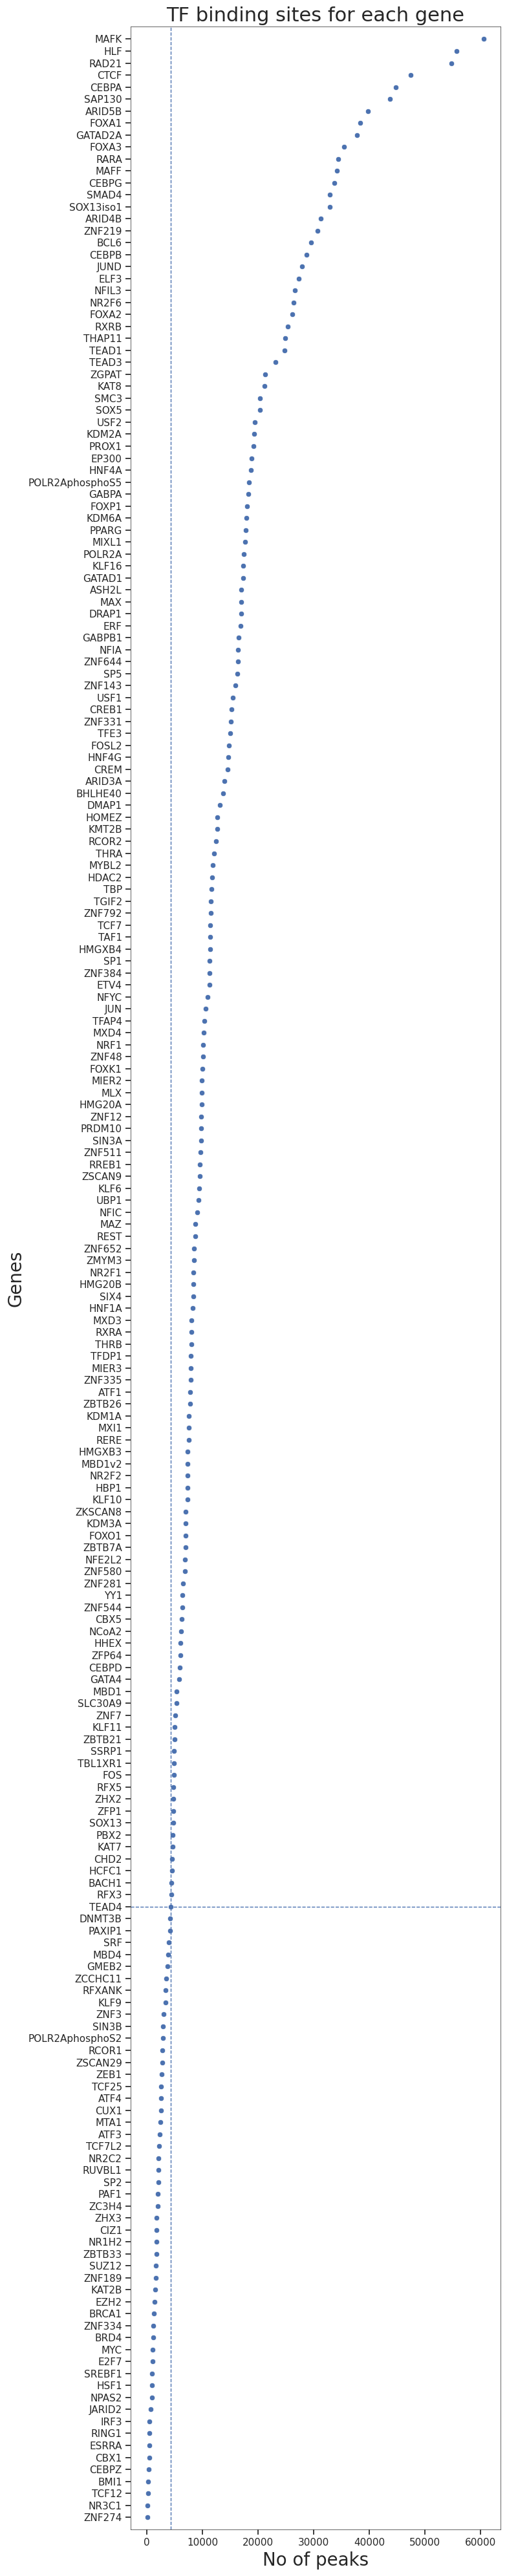

In [18]:
#Filter

#scatter plots odds vs pvalue
sns.set(font="Arial")
sns.set(style="ticks", rc={"axes.linewidth": 0.5})
fig, ax = plt.subplots(figsize=(8, 40))
grid=sns.scatterplot(y="Gene", x="Length_filtered", data=chip_sites)

#lables
ax.set_ylabel("Genes",size = 20)
ax.set_xlabel("No of peaks",size = 20)
ax.set_title('TF binding sites for each gene', size=22)

#grid lines
plt.axvline(4335.75, 0, 160, linewidth=1, ls='--')
plt.axhline("TEAD4", linewidth=1, ls='--')

# Tighter layout by removing vertical padding
ax.margins(y=0.005)  # Reduce y-axis margins
plt.tight_layout()
plt.show()

#### Occupancy map annotations

List of CAP experiments detailing target protein, DBF (direct DNA-binding factor) or CR/CF (chromatin regulator/cofactor), annotation from IDEAS clustering, total peaks called in each experiment, and whether the assay was traditional ChIP-seq or tagged CETCh-seq. - Occupany maps paper supplementary 1

In [34]:
annot = pd.read_csv(ANNOT_FILE, sep="\t")
annot

,0,Target,Category,Annotation,Final Annotation,Peak_count,Assay
0,1.0,MAFF_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,34203,ChIP-seq
1,2.0,MAFK_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,60606,ChIP-seq
2,3.0,BMI1_human,CR/CF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,301,ChIP-seq
3,4.0,ZNF274_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,134,ChIP-seq
4,5.0,EZH2_human,CR/CF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,1934,ChIP-seq
...,...,...,...,...,...,...,...
203,204.0,ZNF580[FLAG],DBF,Cluster V (Promoter and Enhancer-like regions),Promoter_and_Enhancer_like,8109,CETCH-seq
204,205.0,ZSCAN29_iso1[FLAG],DBF,Cluster V (Promoter and Enhancer-like regions),Promoter_and_Enhancer_like,3278,CETCH-seq
205,206.0,ZSCAN9[FLAG],DBF,Cluster V (Promoter and Enhancer-like regions),Promoter_and_Enhancer_like,10726,CETCH-seq
206,207.0,PAF1_v1[FLAG],CR/CF,Cluster VI (Active Gene Body regions),Active_Gene_Body,2604,CETCH-seq


In [27]:
# Clean annotation dataframe
annot = annot.copy()
annot = annot.drop(columns=["0"], errors = "ignore")

# Extract TF name from Target
annot["TF"] = (annot["Target"].str.split("_").str[0].str.replace("[FLAG]", "", regex=False))
annot["suffix"] = annot["Target"].str.split("_").str[1]

# Check
annot.head()

,Target,Category,Annotation,Final Annotation,Peak_count,Assay,TF,suffix
0,MAFF_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,34203,ChIP-seq,MAFF,human
1,MAFK_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,60606,ChIP-seq,MAFK,human
2,BMI1_human,CR/CF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,301,ChIP-seq,BMI1,human
3,ZNF274_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,134,ChIP-seq,ZNF274,human
4,EZH2_human,CR/CF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,1934,ChIP-seq,EZH2,human


In [28]:
annot["suffix"].unique()

array(['human', nan, 'v2[FLAG]', 'v1[FLAG]', 'iso1[FLAG]', 'iso2[FLAG]'],
      dtype=object)

In [29]:
annot["TF"].unique()

array(['MAFF', 'MAFK', 'BMI1', 'ZNF274', 'EZH2', 'ARID3A', 'ARID5B',
       'CEBPA', 'CEBPG', 'EP300', 'ESRRA', 'FOSL2', 'FOXA1', 'FOXA2',
       'FOXA3', 'FOXO1', 'FOXP1', 'GATAD2A', 'HDAC2', 'HHEX', 'HMG20A',
       'HMG20B', 'HNF1A', 'HNF4A', 'HNF4G', 'HOMEZ', 'KDM1A', 'MBD4',
       'MLX', 'MTA1', 'NCoA2', 'NFIA', 'NFIC', 'NFIL3', 'NR2F1', 'NR2F2',
       'NR2F6', 'PAXIP1', 'PPARG', 'PROX1', 'RARA', 'RCOR2', 'RERE',
       'RREB1', 'RXRA', 'RXRB', 'SIX4', 'SMAD4', 'SOX13', 'SOX5', 'TCF12',
       'TCF7', 'TCF7L2', 'TEAD1', 'TEAD3', 'TEAD4', 'THRB', 'ZEB1',
       'ZKSCAN8', 'ZMYM3', 'ZNF219', 'ZNF644', 'BACH1', 'HLF', 'JUN',
       'JUND', 'KAT2B', 'NFE2L2', 'ZNF7', 'ATF4', 'BCL6', 'MIER2',
       'MIXL1', 'SSRP1', 'TFAP4', 'ZNF3', 'ZNF384', 'ZNF652', 'CEBPB',
       'CTCF', 'RAD21', 'SMC3', 'ZNF143', 'KDM6A', 'ATF3', 'BRCA1',
       'CBX1', 'CEBPZ', 'CHD2', 'CIZ1', 'E2F7', 'GABPB1', 'GMEB2', 'HBP1',
       'HCFC1', 'HMGXB4', 'IRF3', 'JARID2', 'KAT7', 'KDM2A', 'KLF10',
       'KLF6

In [30]:
chip_annot = chip.merge(annot,left_on="Gene",right_on="TF",how="left")
chip_annot.head()

,Gene,Length_filtered,Target,Category,Annotation,Final Annotation,Peak_count,Assay,TF,suffix
0,MAFK,60586,MAFK_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,60606.0,ChIP-seq,MAFK,human
1,HLF,55753,HLF[FLAG],DBF,Cluster II (Enhancer-like regions),Enhancer_like,55814.0,CETCH-seq,HLF,NaN
2,RAD21,54820,RAD21[FLAG],DBF,Cluster III (CTCF Bound regions),CTCF_Bound,54870.0,CETCH-seq,RAD21,NaN
3,CTCF,47498,CTCF,DBF,Cluster III (CTCF Bound regions),CTCF_Bound,47501.0,ChIP-seq,CTCF,NaN
4,CEBPA,44752,CEBPA[FLAG],DBF,Cluster II (Enhancer-like regions),Enhancer_like,45299.0,CETCH-seq,CEBPA,NaN


In [31]:
chip_annot_156 = chip_annot.dropna(subset=["Target"]).copy()
chip_annot_156.head()

,Gene,Length_filtered,Target,Category,Annotation,Final Annotation,Peak_count,Assay,TF,suffix
0,MAFK,60586,MAFK_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,60606.0,ChIP-seq,MAFK,human
1,HLF,55753,HLF[FLAG],DBF,Cluster II (Enhancer-like regions),Enhancer_like,55814.0,CETCH-seq,HLF,NaN
2,RAD21,54820,RAD21[FLAG],DBF,Cluster III (CTCF Bound regions),CTCF_Bound,54870.0,CETCH-seq,RAD21,NaN
3,CTCF,47498,CTCF,DBF,Cluster III (CTCF Bound regions),CTCF_Bound,47501.0,ChIP-seq,CTCF,NaN
4,CEBPA,44752,CEBPA[FLAG],DBF,Cluster II (Enhancer-like regions),Enhancer_like,45299.0,CETCH-seq,CEBPA,NaN


In [32]:
print(len(chip_annot_156))

156


In [41]:
chip_annot_156.columns

Index(['Gene', 'Length_filtered', 'Target', 'Category', 'Annotation',
       'Final Annotation', 'Peak_count', 'Assay', 'TF', 'suffix'],
      dtype='object')

In [33]:
chip_annot_156= chip_annot_156[['TF', 'Target', 'Category', 'Annotation',
       'Final Annotation', 'Length_filtered']]
chip_annot_156.rename({'Length_filtered':'Peak counts(non-overlapping sites with the highest binding strength)'}, inplace = True)

In [34]:
chip_annot_156

,TF,Target,Category,Annotation,Final Annotation,Length_filtered
0,MAFK,MAFK_human,DBF,Cluster I (Heterochromatin and Repressed),Heterochromatin_and_Repressed,60586
1,HLF,HLF[FLAG],DBF,Cluster II (Enhancer-like regions),Enhancer_like,55753
2,RAD21,RAD21[FLAG],DBF,Cluster III (CTCF Bound regions),CTCF_Bound,54820
3,CTCF,CTCF,DBF,Cluster III (CTCF Bound regions),CTCF_Bound,47498
4,CEBPA,CEBPA[FLAG],DBF,Cluster II (Enhancer-like regions),Enhancer_like,44752
...,...,...,...,...,...,...
153,KAT7,KAT7[FLAG],CR/CF,Cluster IV (Promoter-like regions),Promoter_like,4635
154,CHD2,CHD2_human,CR/CF,Cluster IV (Promoter-like regions),Promoter_like,4532
155,HCFC1,HCFC1_human,CR/CF,Cluster IV (Promoter-like regions),Promoter_like,4471
156,BACH1,BACH1_human,DBF,Cluster II (Enhancer-like regions),Enhancer_like,4385


In [35]:
chip_annot_156["Category"].value_counts()

DBF      133
CR/CF     23
Name: Category, dtype: int64

In [36]:
chip_annot_156.to_csv(TABLE_DIR / "Supplementary_Table_1_TFBS_annotations.tsv",sep="\t",index=False)